<a href="https://colab.research.google.com/github/lkostenko/ds_homeworks/blob/main/Kostenko_HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [2]:

medical_df = pd.read_csv('/content/medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [3]:
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


### 1.Методу МНК (з використанням тільки numpy, без scikit learn)

In [4]:
age_with_intercept = np.column_stack(( np.ones(len(non_smoker_df.age)), non_smoker_df.age))

In [5]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [6]:
MNK_coefs = normal_equations(age_with_intercept, non_smoker_df.charges)
MNK_coefs

array([-2091.42055657,   267.24891283])

In [7]:
predictions_MNK = np.dot(age_with_intercept, MNK_coefs)
predictions_MNK

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [36]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [9]:
rmse(non_smoker_df.charges, predictions_MNK)

np.float64(4662.505766636395)

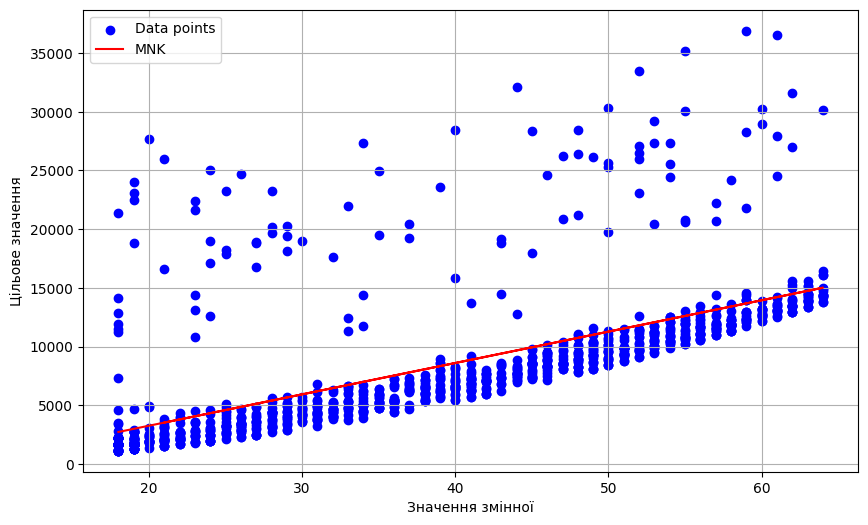

In [10]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(non_smoker_df.age, non_smoker_df.charges, color='blue', label='Data points')
plt.plot(non_smoker_df.age, predictions_MNK, color='red', label='MNK')
plt.xlabel('Значення змінної')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

### 2. Full-Batch градієнтного спуску з numpy

In [11]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors



/tmp/ipython-input-4211100381.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


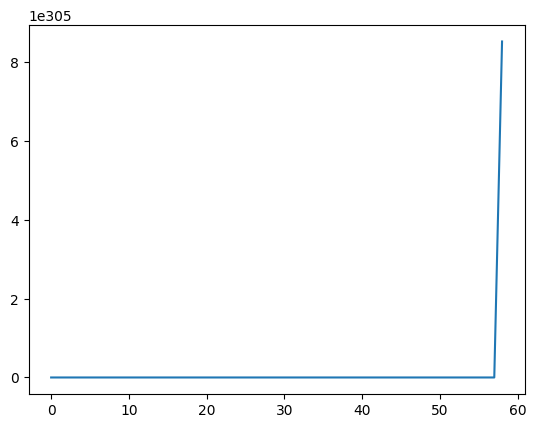

In [12]:
m, b, errors = full_batch_gradient_descent(non_smoker_df.age, non_smoker_df.charges, lr=0.1, epochs=1000)
rmse_fbgd = np.sqrt(errors[-1] / len(non_smoker_df))
m, b, rmse_fbgd, plt.plot(errors);

In [13]:
errors[:5], errors[-5:]

([113878364137.68315,
  1.0991839320638326e+16,
  1.3391942332152962e+21,
  1.6316150540575953e+26,
  1.9878876556111385e+31],
 [nan, nan, nan, nan, nan])

/tmp/ipython-input-4211100381.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient
/usr/local/lib/python3.12/dist-packages/matplotlib/ticker.py:2176: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


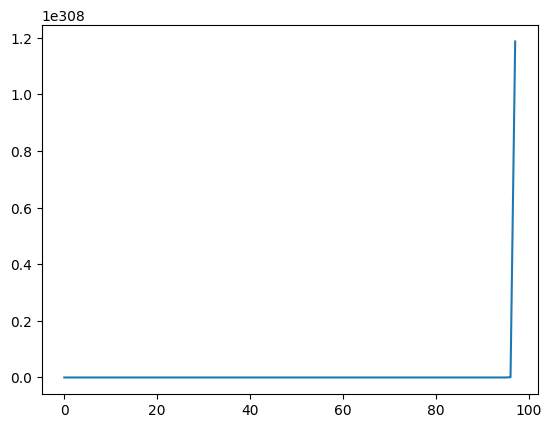

In [14]:
m, b, errors = full_batch_gradient_descent(non_smoker_df.age, non_smoker_df.charges, lr=0.01, epochs=1000)
rmse_fbgd = np.sqrt(errors[-1] / len(non_smoker_df))
m, b, rmse_fbgd, plt.plot(errors);

/tmp/ipython-input-4211100381.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


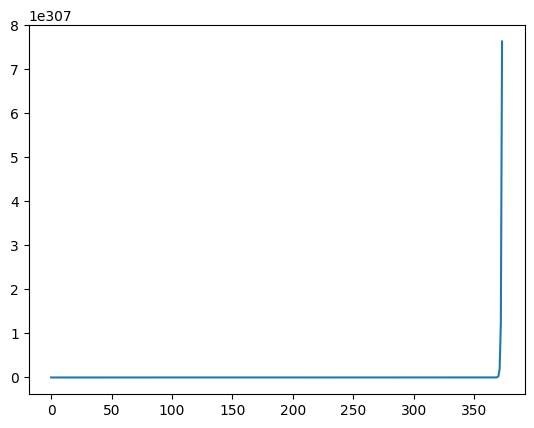

In [15]:
m, b, errors = full_batch_gradient_descent(non_smoker_df.age, non_smoker_df.charges, lr=0.001, epochs=1000)
rmse_fbgd = np.sqrt(errors[-1] / len(non_smoker_df))
m, b, rmse_fbgd, plt.plot(errors);

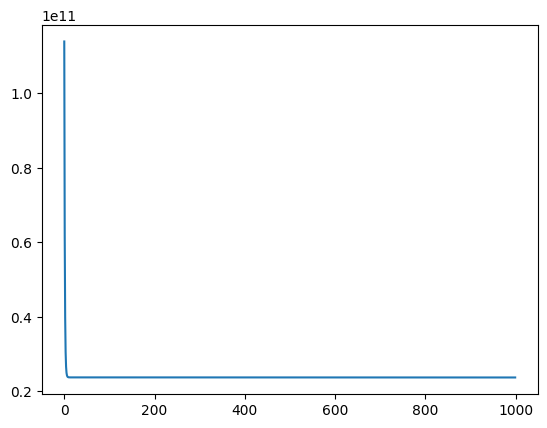

In [16]:
m, b, errors = full_batch_gradient_descent(non_smoker_df.age, non_smoker_df.charges, lr=0.0001, epochs=1000)
rmse_fbgd = np.sqrt(errors[-1] / len(non_smoker_df))
m, b, rmse_fbgd, plt.plot(errors);

In [17]:
errors[-10:]

[23636703147.501495,
 23636680212.48018,
 23636657278.497494,
 23636634345.553394,
 23636611413.647835,
 23636588482.78076,
 23636565552.95214,
 23636542624.16191,
 23636519696.410038,
 23636496769.69646]

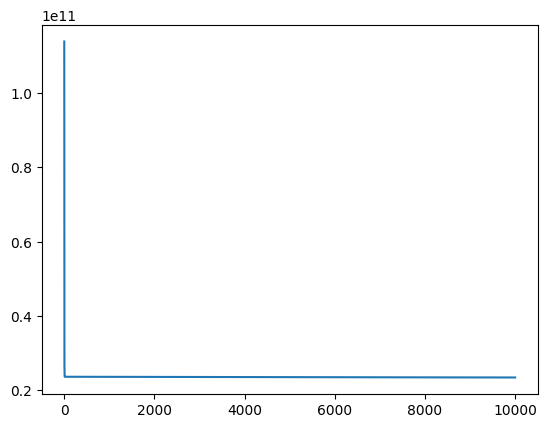

In [27]:
m, b, errors = full_batch_gradient_descent(non_smoker_df.age, non_smoker_df.charges, lr=0.0001, epochs=10000)
rmse_fbgd = np.sqrt(errors[-1] / len(non_smoker_df))
m, b, rmse_fbgd, plt.plot(errors);

In [28]:
predictions_fbgd = m * non_smoker_df.age + b
predictions_fbgd

,age
1,3713.186814
2,6009.307688
3,7157.368126
4,6927.756038
5,6698.143951
...,...
1332,11519.997788
1333,11060.773613
1334,3713.186814
1335,3713.186814


### 3. scikit-learn.LinearRegression

In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [20]:
lin_reg

LinearRegression()

In [22]:
non_smoker_df.age.to_frame()

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [23]:
lin_reg.fit(non_smoker_df.age.to_frame(), non_smoker_df.charges)

LinearRegression()

In [24]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [25]:
predictions_sklearn = lin_reg.predict(non_smoker_df.age.to_frame())

In [26]:
predictions_sklearn

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [37]:
rmse(non_smoker_df.charges, predictions_sklearn)

np.float64(4662.505766636395)

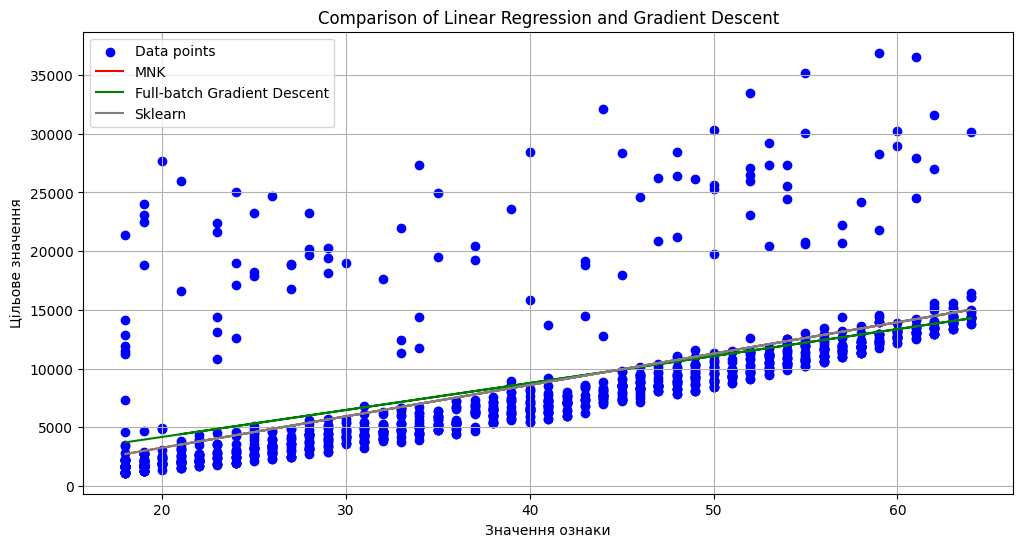

In [34]:
plt.figure(figsize=(12, 6))
plt.scatter(non_smoker_df.age, non_smoker_df.charges, color='blue', label='Data points')
plt.plot(non_smoker_df.age, predictions_MNK, color='red', label='MNK')
plt.plot(non_smoker_df.age, predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(non_smoker_df.age.to_frame(), predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Результати моделей, побудованих за допомогою МНК, Full-Batch градієнтного спуску та scikit-learn.LinearRegression, практично не відрізняються. Отримані коефіцієнти є близькими між собою та узгоджуються з очікуваною поведінкою даних.
Червона лінія (MNK) та cіра лінія (Sklearn)- ідеально накладаються одна на одну. .

Зелена лінія проходить майже по тій самій траєкторії, що й дві інші. Це означає, що алгоритм з lr=0.0001 та 10000 епохами успішно спустився до мінімуму функції втрат.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [49]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [50]:
lin_reg = LinearRegression()

In [55]:
lin_reg.fit(smoker_df.age.to_frame(), smoker_df.charges)

LinearRegression()

In [56]:
lin_reg.coef_, lin_reg.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [57]:
predictions_sklearn = lin_reg.predict(smoker_df.age.to_frame())

In [58]:
rmse(smoker_df.charges, predictions_sklearn)

np.float64(10711.00334810241)

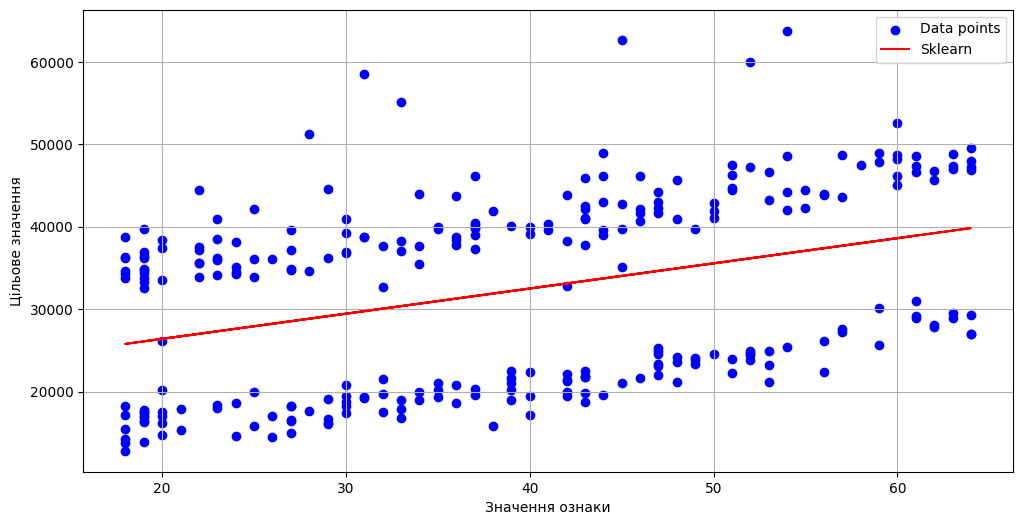

In [60]:
plt.figure(figsize=(12, 6))
plt.scatter(smoker_df.age, smoker_df.charges, color='blue', label='Data points')
plt.plot(smoker_df.age.to_frame(), predictions_sklearn, color='red', label='Sklearn')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Аналіз графіку:

Сині точки не формують одну щільну групу, як це було у випадку з некурцями.

Чітко видно дві окремі групи даних: одна група нижче (витрати 15k-30k), інша група значно вище (витрати 35k-50k+)

Червона лінія регресії проходить посередині між цими двома групами.

Я вважаю, що ця можель погана
- RMSE складає понад 10 711
- Модель завищуватиме ціну для курців, де червона лінія вище синіх точок
- Для верхньої групи - модель занижуватиме ціну (червона лінія нижче синіх точок). Компанія буде втрачати величезні гроші, покриваючи їхнє лікування, яке коштує дорожче, ніж прогноз моделі.

Для курців однієї ознаки age недостатньо.